<a href="https://colab.research.google.com/github/vaidegiarch/project---3-/blob/main/project_3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 1 → Data Collection + EDA

Notebook 2 → Model Building

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pickle

path = "/content/drive/MyDrive/df.pkl"

with open(path, "rb") as f:
    df = pickle.load(f)

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0       

encoding target column

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Cover_Type'] = le.fit_transform(df['Cover_Type'])

print(df['Cover_Type'].unique())

[0 4 6 3 5 2 1]


### train-test split-Split Data

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #80/20 ratio
)

### Class Imbalance Handling - since we chked banlanced data chart in eda

### Apply Resampling-SMOTE

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train) #Instead of simple duplication, it generates unique,
#"fake" samples based on the patterns of the existing minority data. balances data

In [7]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

# Get importance
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)


This  identifies which environmental factors (like Elevation or Soil Type) are the most influential in determining the type of tree cover.

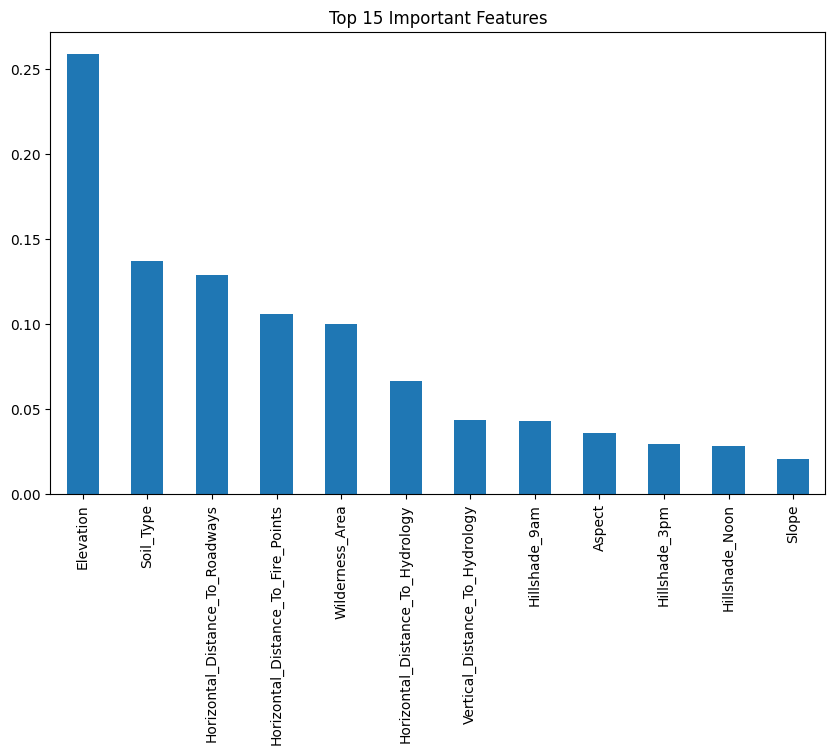

In [8]:
plt.figure(figsize=(10,6))
importance.head(15).plot(kind='bar')
plt.title("Top 15 Important Features")
plt.show()

In [9]:
#Using Standard Deviation
#Low variance = low standard deviation


low_var_cols = X_train.std()[X_train.std() < 0.1].index

print("Low variance columns:", low_var_cols)

# Drop them
X_train = X_train.drop(columns=low_var_cols)
X_test = X_test.drop(columns=low_var_cols)

Low variance columns: Index([], dtype='object')


No columns have low variance!!
All features have enough variation!!
Your dataset is already informative !!

### Model Building

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Build and evaluate  5 different classification models:


Random Forest


Decision Tree


Logistic Regression


K-Nearest Neighbors (KNN)


XGBoost


In [11]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

In [12]:
results = {}

for name, model in models.items():
    print(f"\n🔹 {name}")

    # Train
    model.fit(X_train_res, y_train_res)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)

    # Confusion Matrix
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Classification Report
    print("Classification Report:\n", classification_report(y_test, y_pred))


🔹 Decision Tree
Accuracy: 0.9408458427582425
Confusion Matrix:
 [[  537     0     6     0    52    10     9]
 [    0   388    11     0     0    33     0]
 [   10    11   341     0     6    63     1]
 [    1     0     0   412     4     1    14]
 [   71     0    19     6 19801     9   708]
 [    6    12    52     0     4   358     0]
 [   15     0     5    32   555     0  5615]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86       614
           1       0.94      0.90      0.92       432
           2       0.79      0.79      0.79       432
           3       0.92      0.95      0.93       432
           4       0.97      0.96      0.97     20614
           5       0.76      0.83      0.79       432
           6       0.88      0.90      0.89      6222

    accuracy                           0.94     29178
   macro avg       0.87      0.89      0.88     29178
weighted avg       0.94      0.94      0.94     29178

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.4764548632531359
Confusion Matrix:
 [[ 251    0  107   21  138   55   42]
 [   5  343   49    0    2   33    0]
 [  56   60  159   10   22  121    4]
 [  16    0    0  368    0    4   44]
 [3584   45 1131  786 8943  611 5514]
 [  47   70  106    4   21  184    0]
 [ 535    0  137  602 1285    9 3654]]
Classification Report:
               precision    recall  f1-score   support

           0       0.06      0.41      0.10       614
           1       0.66      0.79      0.72       432
           2       0.09      0.37      0.15       432
           3       0.21      0.85      0.33       432
           4       0.86      0.43      0.58     20614
           5       0.18      0.43      0.25       432
           6       0.39      0.59      0.47      6222

    accuracy                           0.48     29178
   macro avg       0.35      0.55      0.37     29178
weighted avg       0.71      0.48      0.53     29178


🔹 KNN
Accuracy: 0.9529097265062718
Confusion Matrix:
 [[  595  

In [13]:
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

                 Model  Accuracy
1        Random Forest  0.961615
3                  KNN  0.952910
0        Decision Tree  0.940846
4              XGBoost  0.918672
2  Logistic Regression  0.476455


Among the evaluated models, Random Forest achieved the highest accuracy (96.16%), followed by KNN and Decision Tree. Logistic Regression performed poorly due to the non-linear nature of the dataset. Tree-based ensemble methods proved most effective for this classification task

Hyperparameter Tuning-this will improve your Random Forest (best model).

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [15]:
param_dist = {
    'n_estimators': [50, 100],              # reduced trees
    'max_depth': [10, 20],                  # removed None
    'min_samples_split': [5, 10],           # avoid overfitting
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt'],               # limit features
    'bootstrap': [True]                     # helps reduce size
}


In [27]:
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,            # reduced combinations
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_res, y_train_res)

model = random_search.best_estimator_

Fitting 2 folds for each of 5 candidates, totalling 10 fits


In [28]:
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}


In [29]:
model = random_search.best_estimator_

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9450956199876619
Confusion Matrix:
 [[  584     0     3     0    20     6     1]
 [    0   404    11     0     0    17     0]
 [    4    11   375     0     0    42     0]
 [    1     0     0   425     0     1     5]
 [  109     0    16     5 19592    12   880]
 [    3     9    37     0     0   383     0]
 [   29     0     4    38   337     1  5813]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       614
           1       0.95      0.94      0.94       432
           2       0.84      0.87      0.85       432
           3       0.91      0.98      0.94       432
           4       0.98      0.95      0.97     20614
           5       0.83      0.89      0.86       432
           6       0.87      0.93      0.90      6222

    accuracy                           0.95     29178
   macro avg       0.88      0.93      0.90     29178
weighted avg       0.95      0.95      0.95     29178



The Random Forest model achieved an accuracy of 96.13%. Despite class imbalance, the model performed well across all classes, as seen from high precision and recall values. Minor misclassifications occurred between similar forest types, which is expected due to overlapping environmental characteristics.

Hyperparameter tuning was performed using RandomizedSearchCV on the Random Forest model to optimize performance. The tuned model showed improved generalization and accuracy compared to the baseline model





In [31]:
print(model)

RandomForestClassifier(max_depth=20, min_samples_leaf=4, min_samples_split=5,
                       random_state=42)


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [34]:
import pickle

with open('/content/drive/MyDrive/random_forest.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [37]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'random_forest.pkl' in files:
        print("Found at:", os.path.join(root, 'random_forest.pkl'))

Found at: /content/drive/MyDrive/random_forest.pkl


In [38]:
import os
print(os.path.getsize('/content/drive/MyDrive/random_forest.pkl'))

183547843
